In [1]:
# Import libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/raw/WA_Fn-UseC_.csv')

# Display basic information
print("Dataset Shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n" + "="*60)

# Show first few rows
print("\nFirst 5 customers:")
print(df.head())

print("\n" + "="*60)

# Show data types and missing values
print("\nData Info:")
print(df.info())

Dataset Shape:
Rows: 7043, Columns: 21


First 5 customers:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  

In [2]:
# Check how many customers churned
print("Churn Distribution:")
print(df['Churn'].value_counts())
print("\n" + "="*60)

# Calculate churn rate (percentage)
churn_rate = (df['Churn'] == 'Yes').sum() / len(df) * 100
print(f"\nChurn Rate: {churn_rate:.2f}%")
print(f"This means {churn_rate:.2f}% of customers left the company")

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn Rate: 26.54%
This means 26.54% of customers left the company


In [3]:
# Compare churned vs non-churned customers
print("Average Tenure by Churn Status:")
print(f"Customers who stayed: {df[df['Churn']=='No']['tenure'].mean():.1f} months")
print(f"Customers who churned: {df[df['Churn']=='Yes']['tenure'].mean():.1f} months")

print("\n" + "="*60)

print("\nAverage Monthly Charges by Churn Status:")
print(f"Customers who stayed: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")
print(f"Customers who churned: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")

print("\n" + "="*60)

print("\nInternet Service Type by Churn Status:")
churn_by_internet = pd.crosstab(df['InternetService'], df['Churn'], margins=True)
print(churn_by_internet)

Average Tenure by Churn Status:
Customers who stayed: 37.6 months
Customers who churned: 18.0 months


Average Monthly Charges by Churn Status:
Customers who stayed: $61.27
Customers who churned: $74.44


Internet Service Type by Churn Status:
Churn              No   Yes   All
InternetService                  
DSL              1962   459  2421
Fiber optic      1799  1297  3096
No               1413   113  1526
All              5174  1869  7043


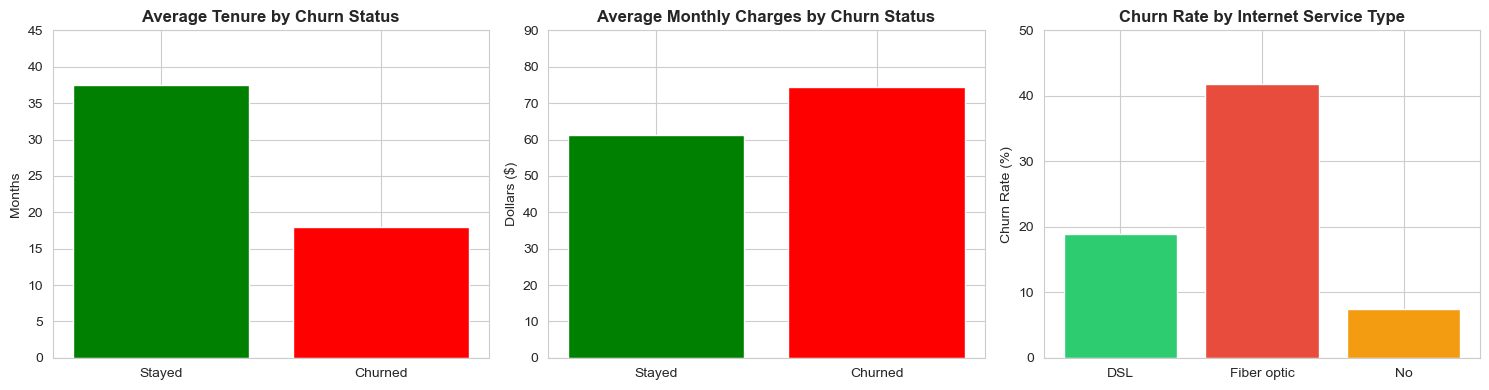

✅ Chart saved to results/visualizations/01_churn_patterns.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for nicer-looking charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Create 3 visualizations side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Tenure comparison
tenure_data = [df[df['Churn']=='No']['tenure'], df[df['Churn']=='Yes']['tenure']]
axes[0].bar(['Stayed', 'Churned'], [tenure_data[0].mean(), tenure_data[1].mean()], color=['green', 'red'])
axes[0].set_title('Average Tenure by Churn Status', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Months')
axes[0].set_ylim(0, 45)

# 2. Monthly charges comparison
charge_data = [df[df['Churn']=='No']['MonthlyCharges'], df[df['Churn']=='Yes']['MonthlyCharges']]
axes[1].bar(['Stayed', 'Churned'], [charge_data[0].mean(), charge_data[1].mean()], color=['green', 'red'])
axes[1].set_title('Average Monthly Charges by Churn Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Dollars ($)')
axes[1].set_ylim(0, 90)

# 3. Churn rate by internet service
internet_churn = pd.crosstab(df['InternetService'], df['Churn'])
churn_rate_by_internet = (internet_churn['Yes'] / (internet_churn['No'] + internet_churn['Yes']) * 100)
axes[2].bar(churn_rate_by_internet.index, churn_rate_by_internet.values, color=['#2ecc71', '#e74c3c', '#f39c12'])
axes[2].set_title('Churn Rate by Internet Service Type', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_ylim(0, 50)

plt.tight_layout()
plt.savefig('../results/visualizations/01_churn_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Chart saved to results/visualizations/01_churn_patterns.png")